# Project 6: Image Classification with Deep Learning



This project introduces us to deep learning. The deep learning process is a huge leap forward in data science and the field is less than 15 years old. The processing is significantly different from our previous projects so you will basically be provided a walkthrough document delineating the steps - much like Project 1. Deep learning is fascinating and I just want you to go through the process so you can appreciate its power.



The data collection portion of deep learning projects is a rather complex task. In other words, there is no CSV file that we can load to serve as our training data. Constructing a training data set is a rather large undertaking. We have imported all the training images (took hours) and I will show you how you can load the training data through the "pickle" process.



There are three files in this data set:
- [the feature set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle ), i.e. images of dogs and cats ( mostly )
- [the target set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle ), i.e. the label (0/1) that something is a dog or cat ( mostly )
- [a test image]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg )





This project will classify new, unseen images of cats and dogs. This was one of the first big success stories of deep learning and we will go through the process of building a learning algorithm that will do this task. Distinguishing a picture of a cat from a picture of a dog is easy for humans to do, but had been notoriously difficult to get a computer learning to perform well on the task. Deep learning solved that.


The same data sets as above, but you can copy the links by viewing the markdown directly to bypass Google Colab's annoying "You are leaving Colab" link.




https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg


In [1]:
import pandas as pd


In [2]:
import tensorflow.keras as keras
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

In [3]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [4]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [5]:
# have 24,946 images then demensions of 100 by 100 by 1
image_array.shape

(24946, 100, 100, 1)

In [6]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [7]:
target = pd.read_pickle( target_url )
type(target)


list

In [8]:
image_url = ''

In [9]:
# we will need to machine learn code to distinguish cats and dogs

In [10]:
image_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"

# 2. Convert target list 'target' into a numpy array
y = np.array(target)
X = image_array

In [57]:
X = X[:1000]
y = y[:1000]

In [58]:
# Split your actual cat/dog dataset (X and y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [59]:
#has to be numpy
(
  type(X_train),
  type(y_train),
  type(X_test),
  type(y_test)
)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

In [60]:
# this is the shape of my training and testing adding the train X and train y it = 24946 which is how many images I have
(
  X_train.shape,
  y_train.shape,
  X_test.shape,
  y_test.shape
)

((350, 100, 100, 1), (350,), (150, 100, 100, 1), (150,))

In [61]:
X_train.shape

(350, 100, 100, 1)

In [62]:
# I have a lot of images i should cut it down because it will take a long time to train and test run


In [63]:
X_train.shape[1:]

(100, 100, 1)

In [64]:
X_train[1]

array([[[214],
        [221],
        [221],
        ...,
        [171],
        [176],
        [170]],

       [[217],
        [221],
        [222],
        ...,
        [177],
        [176],
        [166]],

       [[218],
        [221],
        [221],
        ...,
        [175],
        [173],
        [167]],

       ...,

       [[164],
        [173],
        [169],
        ...,
        [120],
        [112],
        [101]],

       [[167],
        [169],
        [148],
        ...,
        [114],
        [121],
        [107]],

       [[159],
        [157],
        [145],
        ...,
        [119],
        [105],
        [100]]], dtype=uint8)

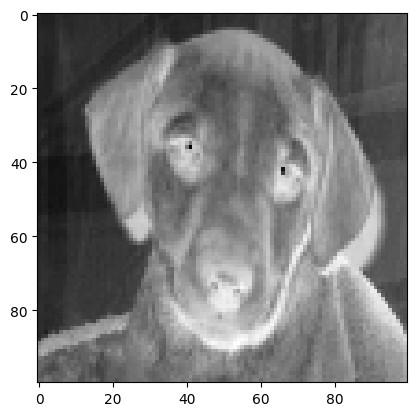

In [65]:
plt.imshow( X_train[1], cmap = plt.cm.gray_r )
plt.show()

In [96]:
# Normalizing my picture
image_array = image_array / 255.0
#this is scaling the images from 0-1 for the binary process

In [97]:
print(X_train.min(), X_train.max())

0.0 0.7573453885187765


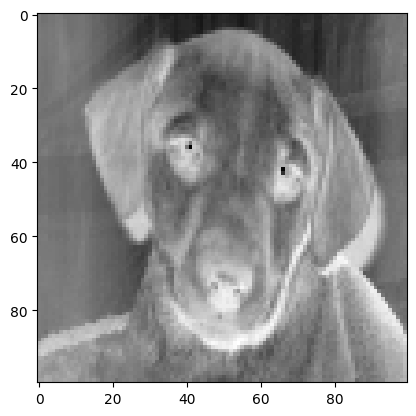

In [77]:
plt.imshow(X_train[1],cmap=plt.cm.gray_r)
plt.show()

In [78]:
# training my model we well see what happens

In [79]:
model = Sequential()

In [80]:
# Define input layer
model.add(
  Input(
    shape=X_train.shape[1:],
    name="model_input",
  ),
)


In [81]:
# now gonna make my hidden layers im gonna make 1 and up the hidden numbers
# Define first hidden layer
model.add(
  Conv2D(
    name = "Conv1",
    filters = 40,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)


In [82]:
#Define second hidden layer
model.add(
  Conv2D(
    name = "Conv2",
    filters = 40,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)


In [83]:
# Define Third hidden layer
#model.add(
#  Conv2D(
#    name = "Conv3",
#    filters = 80,
#    kernel_size = (1,1),
#    activation = 'relu',
#  )
#)

#model.add(
#  MaxPooling2D(pool_size=(2,2))
#)


In [84]:
# Flatten data to be used in output layer
model.add(
    Flatten()
)

# Define output layer
model.add(
  Dense(
    name = "output",
    units = 2,
    activation = 'softmax',
  )
)


In [85]:
# Compile model
model.compile(
  optimizer = 'adam',
  loss = 'sparse_categorical_crossentropy',
  metrics = ['accuracy'],
)


Fit Model

In [86]:
# Fit model
# i have 17,462 images this will take really long to train I have to find a way to decrease batch size
# it aoutomatically had a batch size of 546
#went back and lowered it to 500 images for now
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 449ms/step - accuracy: 0.4886 - loss: 0.6976
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 565ms/step - accuracy: 0.5343 - loss: 0.6900
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 404ms/step - accuracy: 0.5886 - loss: 0.6798
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 406ms/step - accuracy: 0.6286 - loss: 0.6644
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 513ms/step - accuracy: 0.6657 - loss: 0.6351


In [87]:
# The Training Results
# ***** output unit was 10 ******************************* ( found out after )
# *(500 images) (2 hidden) (epoch = 2) (test=30%)
# attempt 1: accur - 0.5712 loss - 1.8857 ( both filters=40)
# attempt 2: accur - 0.4771 loss - 1.4698 ( both filters=64)
# attempt 3: accur - 0.5171 loss - 1.5952 ( both filters=80)                           ************before Normalization*******************
# *(500 images) (2 hidden) (epoch = 5) (test=30%)
# attempt 1: accur - 0.8343 loss - 0.3515 ( both filters=40)
# attempt 2: accur - 0.9743 loss - 0.1058 ( both filters=64)
# attempt 3: accur - 0.8743 loss - 0.3149 ( both filters=80)

In [88]:
# The Training Results
# ***** output unit was 2 ******************************* ( should be 2 because we have 2 kinds of classes, cat and dog)

# *(500 images) (2 hidden) (epoch = 5) (test=30%)
# attempt 1: accur - 0.8686 loss - 0.3349 ( both filters=40)
# attempt 2: accur - 0.7543 loss - 0.4530 ( both filters=64)                          ************before Normalization*******************
# attempt 3: accur - 0.8514 loss - 0.3538 ( both filters=80)

In [89]:
# The Training Results
# ***** Added a 3rd hidden layer to see if there are any improvements to the testing *******************************
# *(500 images) (2 hidden) (epoch = 5) (test=30%)
# attempt 1: accur - 0.6429 loss - 0.6448 ( both filters=40)
# attempt 2: accur -  loss -  ( both filters=64)
# attempt 3: accur - 0.6743 loss - 0.6067 ( both filters=80)                          ************before Normalization*******************

In [90]:
# The Training Results
# ***** Kernel changed (1,1) *******************************
# was just as bad I didnt even type the results                          ************before Normalization*******************

In [91]:
# Ramped up the amount that I am testing on
#************* 1,000 images testing and training total*****************

With normalization in place

In [92]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 98, 98, 40)     │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 49, 49, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 47, 47, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 23, 23, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 21160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │        42,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,488 (669.88 KB)

 Trainable params: 57,162 (223.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 114,326 (446.59 KB)

In [93]:
# Testing (The results that matter)
val_loss, val_acc = model.evaluate(X_test, y_test)
print(val_loss)
print(val_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.4933 - loss: 0.7292
0.7291917204856873
0.4933333396911621


In [316]:
# Testing
# *(500 images) (2 hidden) (epoch = 2) (test=30%)
# 1st attempt: Accuracy - .519  loss - 1.09 ( both filters = 40)
# 2nd attempt: Accuracy - .506  loss - 0.83 ( both filters = 64)
# 3rd attempt: Accuracy - .480  loss - 0.97 ( both filters = 80)

# *(500 images) (2 hidden) (epoch = 5) (test=30%)
# 1st attempt: accur - 0.540 loss - 1.07 ( both filters=40)                          ************before Normalization*******************
# 2nd attempt: accur - 0.546 loss - 1.60 ( both filters=64)
# 3rd attempt: accur - 0.540 loss - 0.91 ( both filters=80)

In [283]:
# my testing results are not getting better theya re still aweful. why is this?

In [284]:
# Testing
# ***** output unit was 2 ******************************* ( should be 2 because we have 2 kinds of classes, cat and dog)

# *(500 images) (2 hidden) (epoch = 5) (test=30%)
# attempt 2: accur - 0.506 loss - 0.8738 ( both filters=40)
# attempt 1: accur - 0.560 loss - 0.7385 ( both filters=64)                          ************before Normalization*******************
# attempt 3: accur - 0.600 loss - 0.8691 ( both filters=80)

In [285]:
# Testing
# ***** Added a 3rd hidden layer to see if there are any improvements to the testing *******************************
# *(500 images) (2 hidden) (epoch = 5) (test=30%)
# attempt 1: accur - 0.4200 loss - 0.8959 ( both filters=40)                          ************before Normalization*******************
# attempt 2: accur -  loss -  ( both filters=64)
# attempt 3: accur - 0.5333 loss - 0.7373 ( both filters=80)

using model for predictions

In [286]:
# make predictions based on testing set
predictions = model.predict(X_test)


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 440ms/step


In [287]:
predictions.shape

(150, 2)

([(0, np.float32(48.598255)), (1, np.float32(51.401752))], np.int64(0))

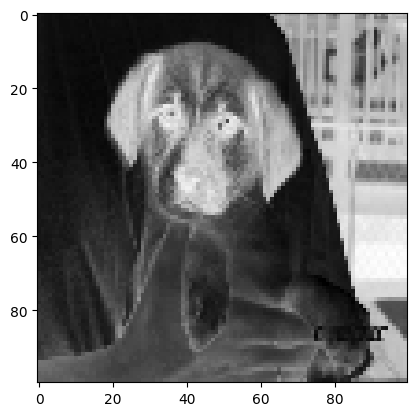

In [389]:
# print out the images
i = 0
filter = ( (predictions).argmax( axis = 1 ) != y_test )
plt.imshow(X_test[ filter ][i], cmap=plt.cm.gray_r)
list(enumerate(predictions[filter][i]*100)), y_test[filter][i]


0: 39.58
1: 60.42
1
1


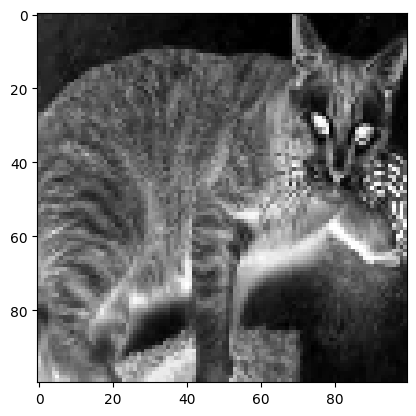

In [291]:
# pick any image from 0 to 27,000
i = 90
# i = 160
# i = 2982


for k, x in enumerate(predictions[i]*100):
  print(f"{k}: {x:.2f}")
print(np.argmax(predictions[i]))
print(y_test[i])
plt.imshow(X_test[i], cmap=plt.cm.gray_r)
plt.show()